In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Configurar o dispositivo (GPU se disponível, caso contrário CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ PyTorch a correr no dispositivo: {device}")

✅ PyTorch a correr no dispositivo: cuda


In [2]:
# 1. Carregar o dataset
df = pd.read_csv('../data/dataset.csv').dropna()

# 2. TF-IDF
vectorizer = TfidfVectorizer(max_features=512)
X = vectorizer.fit_transform(df['text']).toarray()

# 3. Label Encoding (Transforma nomes em 0, 1, 2, 3, 4)
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

# 4. Divisão Treino/Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 5. Converter para Tensores do PyTorch
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

# 6. Criar DataLoaders (Batch Size 32)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

print(f"✅ Dados prontos! Classes detetadas: {encoder.classes_}")

✅ Dados prontos! Classes detetadas: ['google' 'human' 'meta' 'mistral' 'openai']


In [3]:
class DetectorIADeep(nn.Module):
    def __init__(self, input_size, num_classes):
        super(DetectorIADeep, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),  
            nn.ReLU(),
            nn.Dropout(0.3),             
            
            nn.Linear(256, 64),         
            nn.ReLU(),
            nn.Dropout(0.3),            
            
            nn.Linear(64, 32),          
            nn.ReLU(),
            nn.Dropout(0.3),             
            
            nn.Linear(32, num_classes)   
        )
        
    def forward(self, x):
        return self.net(x)

input_size = X_train.shape[1] 

model = DetectorIADeep(input_size=input_size, num_classes=len(encoder.classes_)).to(device)

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)

epochs = 100 
history_loss = []

print("A iniciar o treino no PyTorch...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    history_loss.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Época [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

A iniciar o treino no PyTorch...
Época [10/100] - Loss: 0.5353
Época [20/100] - Loss: 0.3284
Época [30/100] - Loss: 0.1701
Época [40/100] - Loss: 0.1045
Época [50/100] - Loss: 0.0766
Época [60/100] - Loss: 0.0666
Época [70/100] - Loss: 0.0584
Época [80/100] - Loss: 0.0553
Época [90/100] - Loss: 0.0459
Época [100/100] - Loss: 0.0544


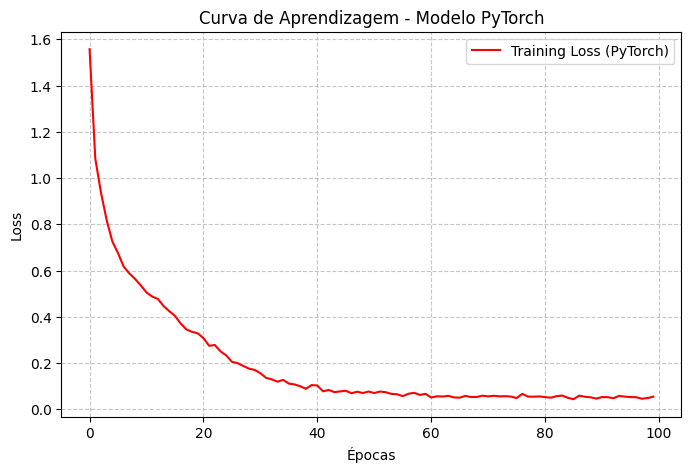

Resultados do Modelo PyTorch
Teste Accuracy: 72.36%
Teste Loss: 1.1775


In [5]:
# 1. Gráfico de Loss
plt.figure(figsize=(8, 5))
plt.plot(history_loss, label='Training Loss (PyTorch)', color='red')
plt.title('Curva de Aprendizagem - Modelo PyTorch')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# 2. Accuracy e Loss no Teste
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == y_test_t).sum().item()
    accuracy = 100 * correct / y_test_t.size(0)
    loss = criterion(outputs, y_test_t).item()

print(f"Resultados do Modelo PyTorch")
print(f"Teste Accuracy: {accuracy:.2f}%")
print(f"Teste Loss: {loss:.4f}")

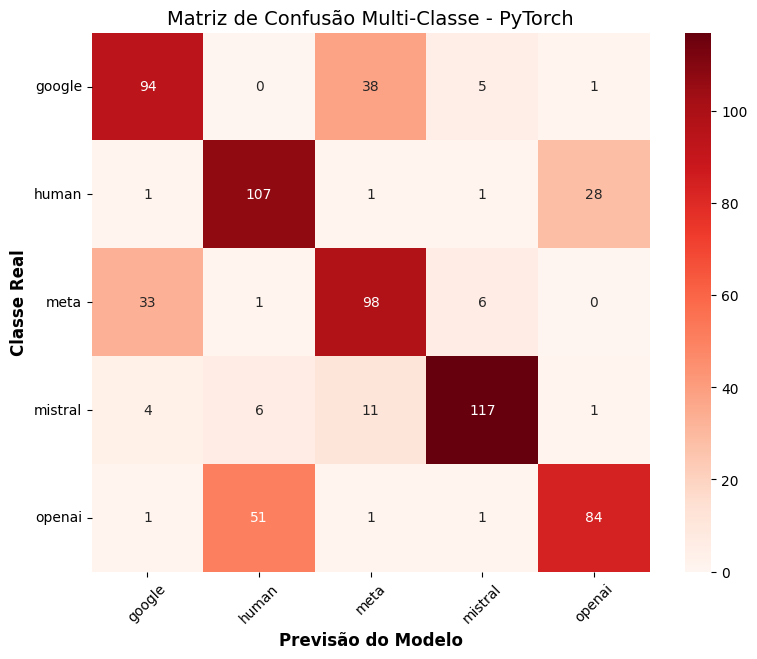

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Colocar modelo em avaliação e obter previsões
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)

# 2. Converter Tensores para arrays Numpy (necessário para o sklearn)
y_true = y_test_t.cpu().numpy()
y_pred = predicted.cpu().numpy()

# 3. Criar a matriz usando os nomes das classes (classes_)
cm = confusion_matrix(y_true, y_pred)
class_names = encoder.classes_

# 4. Plotar o gráfico (Versão Melhorada)
plt.figure(figsize=(9, 7)) # Ligeiramente maior
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', # Mantemos o vermelho para o PyTorch!
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusão Multi-Classe - PyTorch', fontsize=14)

# Rodar as labels do eixo X para facilitar a leitura
plt.xticks(rotation=45) 
plt.yticks(rotation=0)

plt.show()